<a href="https://colab.research.google.com/github/shagun30107-bit/csot-ml-astronomy/blob/main/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q datasets transformers accelerate qwen-vl-utils scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 21.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)



Using: cuda


# STEP-1

In [4]:

from datasets import load_dataset

ds_test = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='test')
y_all = np.array(ds_test['label'])

rng = np.random.default_rng(42)
pos = rng.choice(np.where(y_all == 1)[0], size=20, replace=False)
neg = rng.choice(np.where(y_all == 0)[0], size=20, replace=False)
idx = np.concatenate([pos, neg]); rng.shuffle(idx)
images = [ds_test[int(i)]['image'].convert('RGB') for i in idx]
labels = y_all[idx]
print('sample size:', len(images), 'positives:', int(labels.sum()))



README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

sample size: 40 positives: 20


# STEP-2


README.md:   0%|          | 0.00/313 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/4.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'response'],
    num_rows: 40
})


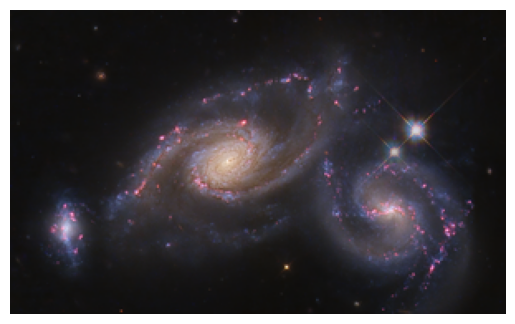

caption: This is a pair of interacting spiral galaxies. They are actually very close together, and not merely nearby on the sky. This image does not show an instance of strong gravitational lensing.


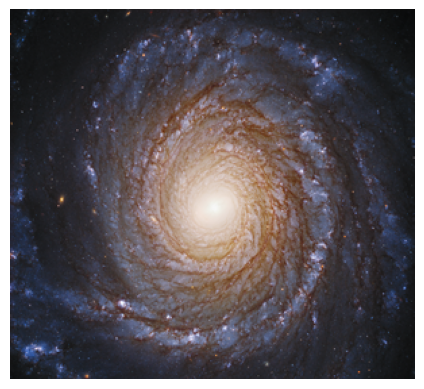

caption: This is a relatively nearby, beautiful spiral galaxy. It does not show an instance of strong gravitational lensing.


In [5]:
ref = load_dataset('Arbie333/gravitational_lensing', split='train')
print(ref)
cap_field = [c for c in ref.column_names if c != 'image'][0]

for i in range(2):
    plt.imshow(ref[i]['image'])
    plt.axis('off')
    plt.show()
    print('caption:', ref[i][cap_field])

# STEP-3


In [6]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

model_id = 'Qwen/Qwen2-VL-2B-Instruct'
vlm = Qwen2VLForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.float16, device_map='auto')
processor = AutoProcessor.from_pretrained(model_id)

PROMPT = (
      'You are assisting an astronomer reviewing telescope cutouts for strong gravitational lensing.\n\n'
      'Look at this image. Strong lensing shows clear arcs, partial Einstein rings, or multiple images '
      'of a background source.\n\n'
      'Answer in this format:\n'
      'VERDICT: yes | no | uncertain\n'
      'EVIDENCE: one or two sentences describing what you see (or do not see)\n'
      'CAUTION: one sentence about what could be confused with lensing (e.g. spiral arms, mergers)')



config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

# STEP-4

In [7]:
raw_answers = []
for img in images:
    messages = [{'role': 'user', 'content': [
        {'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors='pt').to(vlm.device)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=128, do_sample=False)
    reply = processor.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    raw_answers.append(reply)

print(raw_answers[0])



VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


# STEP-5

In [8]:
def parse_verdict(text):
    for line in text.splitlines():
        if line.strip().upper().startswith('VERDICT'):
            v = line.split(':', 1)[1].strip().lower()
            if 'yes' in v:
              return 'yes'
            if 'uncertain' in v:
              return 'uncertain'
            if 'no' in v:
              return 'no'
    return 'uncertain'

verdicts = [parse_verdict(t) for t in raw_answers]
vlm_pred = np.array([1 if v == 'yes' else 0 for v in verdicts])

from sklearn.metrics import classification_report
print(classification_report(labels, vlm_pred, target_names=['not lens', 'lens']))



              precision    recall  f1-score   support

    not lens       0.00      0.00      0.00        20
        lens       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# STEP-6

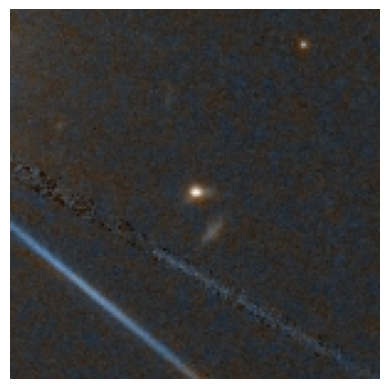

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


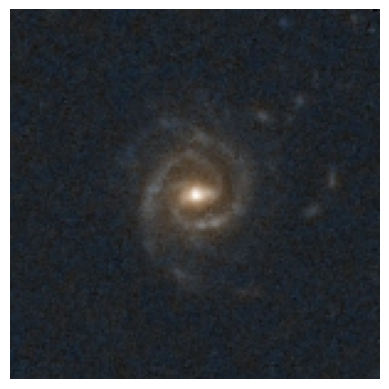

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered around the galaxy and extends outward, indicating the presence of a strong gravitational lens. There are no other visible features such as spiral arms or mergers that could be confused with lensing.
CAUTION: The arc could also be due to the galaxy itself, as it is a common feature of spiral galaxies. However, the arc is clearly visible and does not appear to be due to the galaxy itself.


In [9]:
halluc=[]
for i in range(len(images)):
  if vlm_pred[i] == 1 and labels[i] == 0:
    halluc.append(i)

for i in halluc[:2]:
    plt.imshow(images[i]); plt.axis('off'); plt.show()
    print('VLM said:', raw_answers[i])


# STEP-7 (CNN)

In [10]:
import torch.nn as nn
from torchvision import transforms

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

CLASSES =  ['elliptical', 'spiral', 'spiral_barred']
cnn = GalaxyCNN(num_classes=len(CLASSES)).to(device)
cnn.load_state_dict(torch.load('galaxy_model.pth', map_location=device))
cnn.eval()

t = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
cnn_pred = []
for img in images:
    x = t(img).unsqueeze(0).to(device)
    with torch.no_grad():
        cnn_pred.append(CLASSES[cnn(x).argmax(1).item()])

# STEP-8 (CLIP Scores)

In [12]:
from transformers import CLIPModel, CLIPProcessor

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.to(device).eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print('LOaded on:',device)

import torch.nn.functional as F
lens_prompts = [
      'a strong gravitational lens with an Einstein ring',
      'a gravitational lens arc next to a galaxy',
      'multiple images of a background source due to gravitational lensing']
nonlens_prompts = [
      'a normal galaxy without gravitational lensing',
      'a spiral galaxy with curved arms but no gravitational lens arc',
      'a smooth elliptical galaxy with no lensing features']
all_prompts = lens_prompts + nonlens_prompts
text_inputs = processor(text=all_prompts, return_tensors='pt', padding=True).to(device)

with torch.no_grad():
    outputs = model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"]
    )

text_emb = outputs.pooler_output
text_emb = F.normalize(text_emb, dim=-1)
n_lens = len(lens_prompts)


images = [ex.convert('RGB') for ex in ds_test['image']]
img_embs = []
batch = 64
for start in range(0, len(images), batch):
    chunk = images[start:start+batch]
    inputs = processor(images=chunk, return_tensors='pt').to(device)

    with torch.no_grad():
      outputs = model.vision_model(pixel_values=inputs["pixel_values"])
      emb = model.visual_projection(outputs.pooler_output)   # 768 -> 512

    emb = F.normalize(emb, dim=-1)
    img_embs.append(emb.cpu())

img_emb = torch.cat(img_embs)
print(img_emb.shape)

sims = img_emb @ text_emb.cpu().T
lens_sim = sims[:, :n_lens].mean(dim=1)
nonlens_sim = sims[:, n_lens:].mean(dim=1)
scores = (lens_sim - nonlens_sim).numpy()

print('CLIP score range:', round(float(scores.min()), 3), 'to', round(float(scores.max()), 3))

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

LOaded on: cuda
torch.Size([1476, 512])
CLIP score range: -0.019 to 0.038


# STEP-9

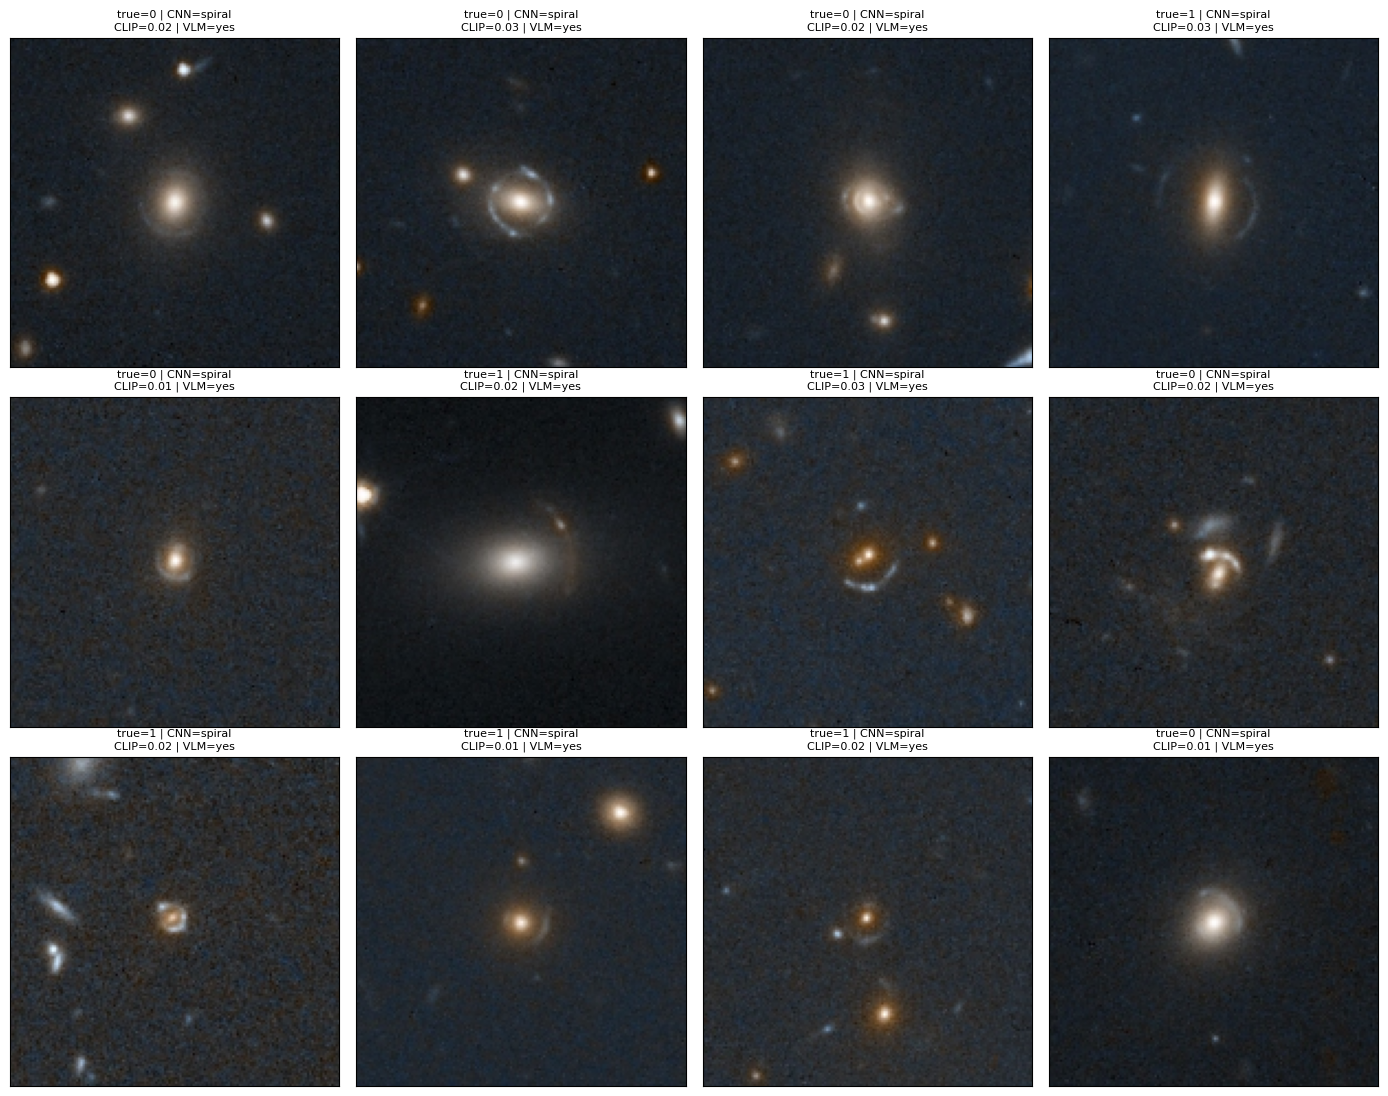

In [14]:
n = min(12, len(images))
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, i in zip(axes.ravel(), range(n)):
    ax.imshow(images[i])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"true={labels[i]} | CNN={cnn_pred[i]}\nCLIP={scores[i]:.2f} | VLM={verdicts[i]}", fontsize=8)
plt.tight_layout()
plt.show()

# Capstone Reflection

**Trust: ** The model loses trust when distinguishing similar galaxy types like spiral and barred spiral, but it earns trust as a tool for flagging potential gravitational lens candidates-not making the final decision.

**The wrong tool:** The Week-3 CNN was trained on Galaxy Zoo 2 for galaxy morphology, not lens detection. Using it to predict lenses is out of domain, so its predictions are not reliable.

**The pipeline:** I would use the CNN for galaxy morphology, CLIP to retrieve lens candidates, a VLM for edge cases and explanations, and keep humans for the final verification.

**Looking back:** AI is powerful, but the key is choosing the right model, writing good prompts, and knowing when human verification is needed.
